In [1]:
# Day 01 : 16/05 05:00 pm

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks/Unsupervised Learning/Mall Customer Segmentation Data/')

['Mall_Customers.csv', 'mall-customer-segmentation.ipynb']

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [5]:

data  = '/content/drive/MyDrive/Colab Notebooks/Unsupervised Learning/Mall Customer Segmentation Data/Mall_Customers.csv'


data = pd.read_csv(data)

data.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
data.shape

(200, 5)

/tmp/ipykernel_720/457381658.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual Income (k$)'])
/tmp/ipykernel_720/457381658.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])
/tmp/ipykernel_720/457381658.py:25: UserWarning: 

`distplot` is a deprecated function and w

<Axes: xlabel='Gender', ylabel='count'>

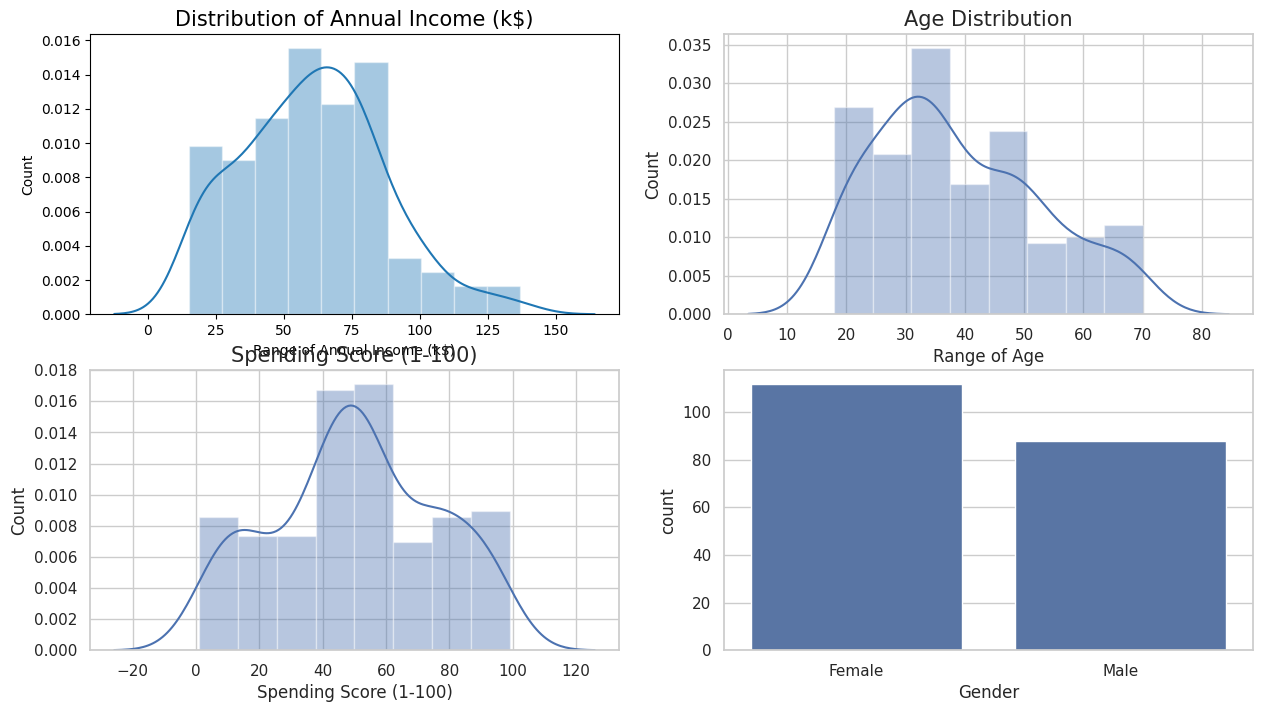

In [9]:

# Annual Income distribution



plt.figure(1, figsize=(15,8))

plt.subplot(2,2,1)
sns.set_theme(style = 'whitegrid')
sns.distplot(data['Annual Income (k$)'])
plt.title('Distribution of Annual Income (k$)', fontsize = 15)
plt.xlabel('Range of Annual Income (k$)')
plt.ylabel('Count')

# Day 02 17/05 11:20 AM
# Age distribution

plt.subplot(2,2,2)
sns.distplot(data['Age'])
plt.title('Age Distribution',fontsize = 15)
plt.xlabel('Range of Age')
plt.ylabel('Count')

# Spending score distribution
plt.subplot(2,2,3)
sns.distplot(data['Spending Score (1-100)'])
plt.title('Spending Score (1-100)',fontsize = 15)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')

# Age distribution
plt.subplot(2,2,4)
sns.barplot(data['Gender'].value_counts())



<Axes: ylabel='Count'>

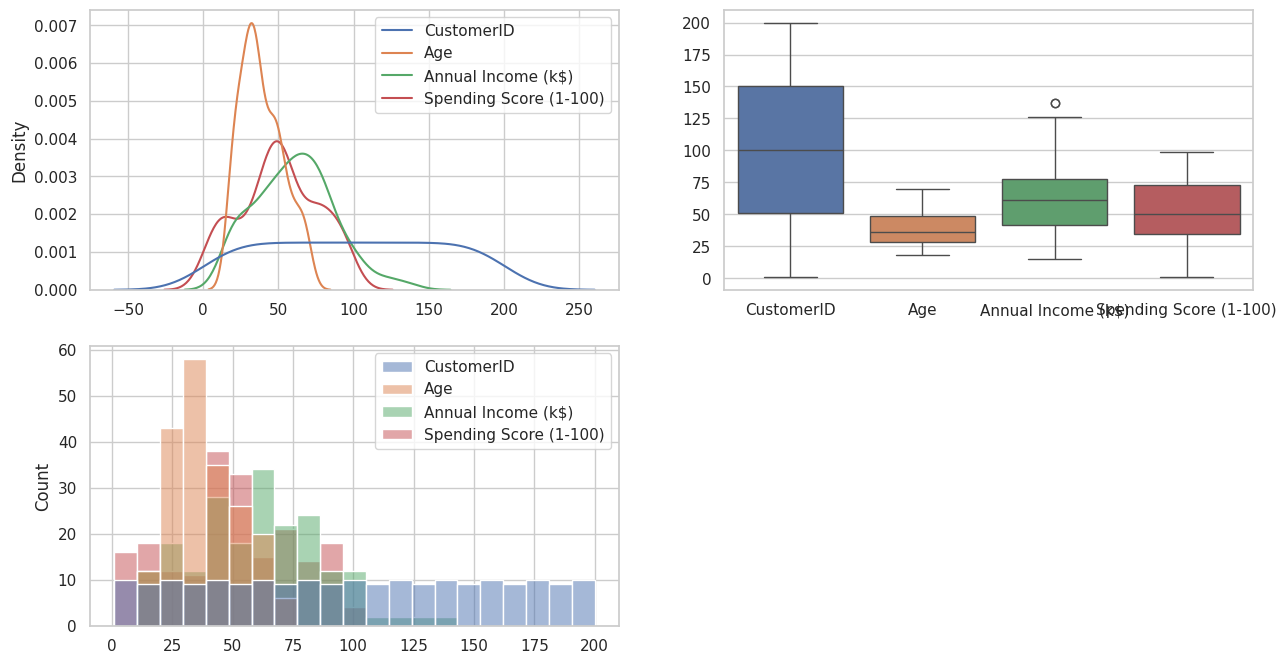

In [10]:

plt.figure(1, figsize=(15,8))

plt.subplot(2,2,1)
sns.kdeplot(data)

plt.subplot(2,2,2)
sns.boxplot(data)

plt.subplot(2,2,3)
sns.histplot(data)

Text(0, 0.5, 'Spending Score')

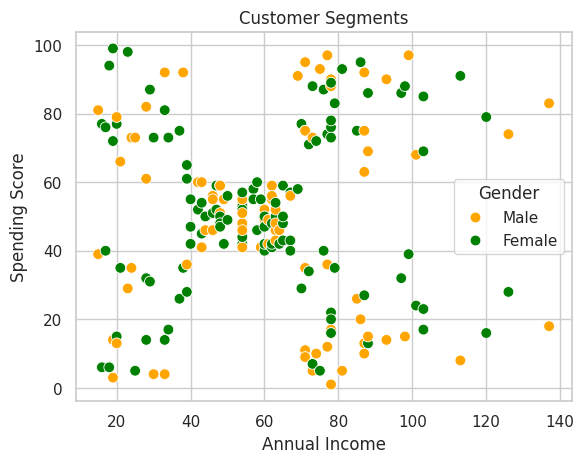

In [42]:
# Clustering based on 2 features

X = data[['Annual Income (k$)','Spending Score (1-100)','Gender']]

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = X, s= 60, hue='Gender', palette=['orange','green'])

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")


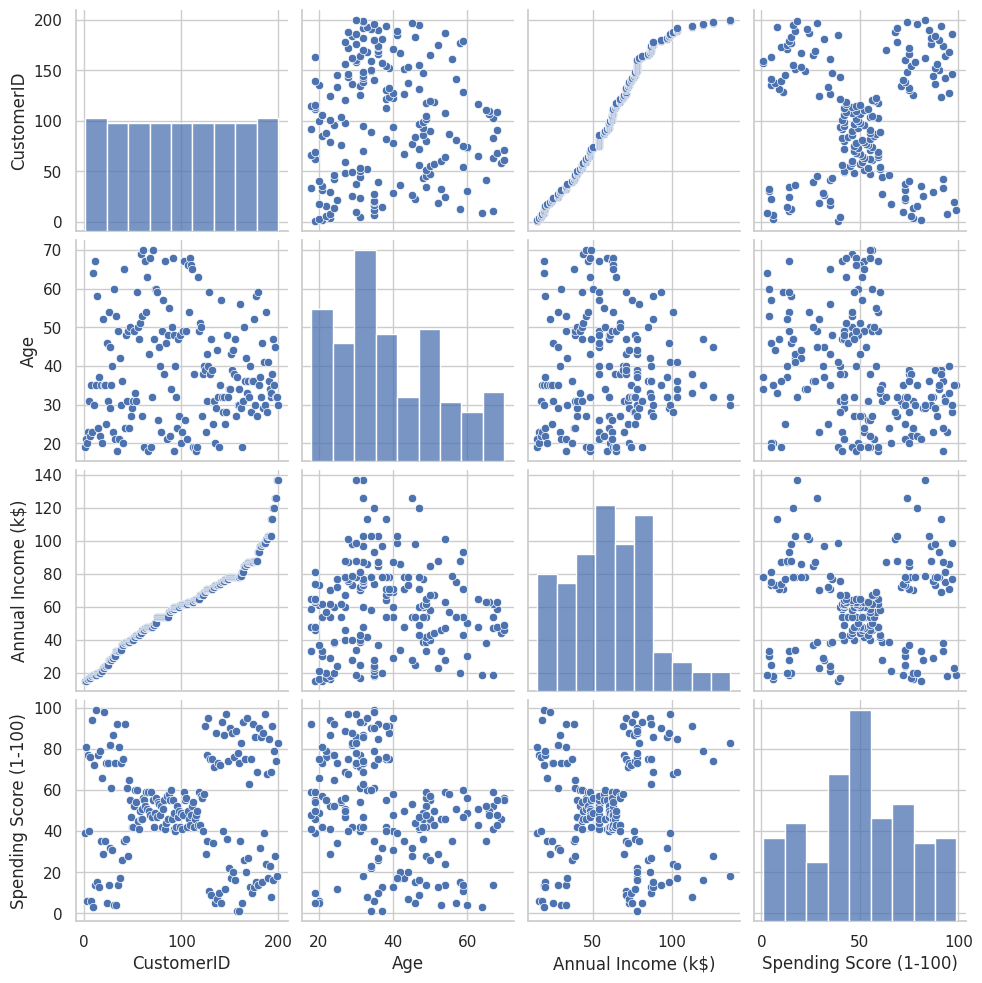

In [12]:
sns.pairplot(data)

In [13]:
corr_mat = data.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

corr_mat


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


<Axes: >

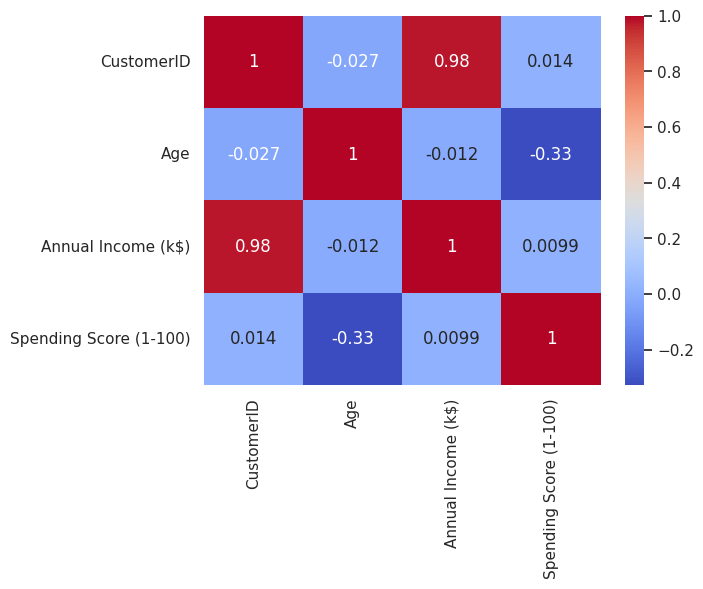

In [14]:
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')


In [90]:
#

X = data[['Annual Income (k$)','Spending Score (1-100)']]

wss = []

for i in range(1,11):
  km = KMeans(i)
  km.fit(X)
  wss.append(km.inertia_)

wss




[269981.28000000014,
 183653.3289473683,
 106348.37306211119,
 73679.78903948837,
 66991.11153756356,
 38858.959975143895,
 32243.894362159568,
 29032.755525675864,
 23260.06368123746,
 20801.1603703593]

Text(0, 0.5, 'Clusters')

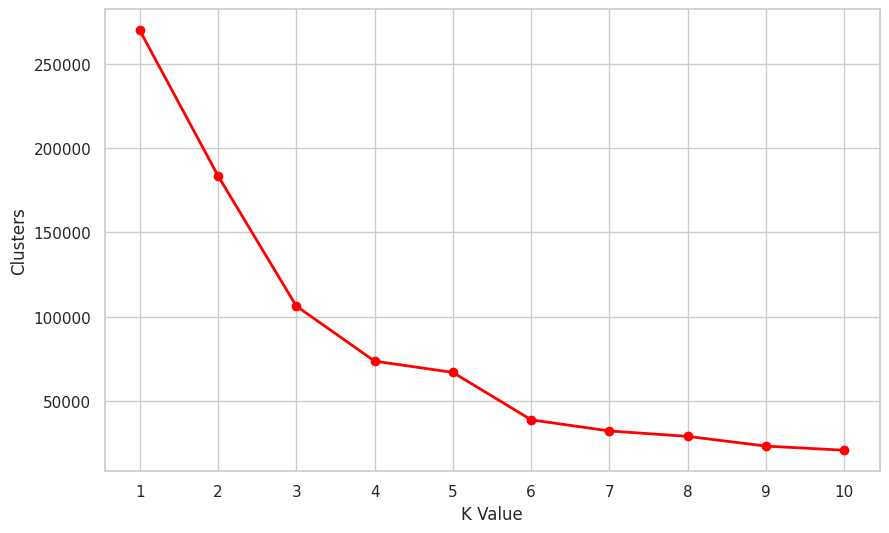

In [91]:
# Elbow Graph

plt.figure(2,figsize=(10,6))

plt.plot(range(1,11), wss, linewidth=2, color='red', marker='o')
plt.xlabel("K Value")
plt.xticks(np.arange(1,11,1))
plt.ylabel("Clusters")



In [92]:
km_model = KMeans(n_clusters=5)

km_model.fit(X)

y = km_model.predict(X)

data['label'] = y

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),label,lable1
0,1,Male,19,15,39,1,3
1,2,Male,21,15,81,4,1
2,3,Female,20,16,6,1,3
3,4,Female,23,16,77,4,1
4,5,Female,31,17,40,1,3


Text(0.5, 1.0, 'Spending Score (1-100) vs Annual Income (k$)')

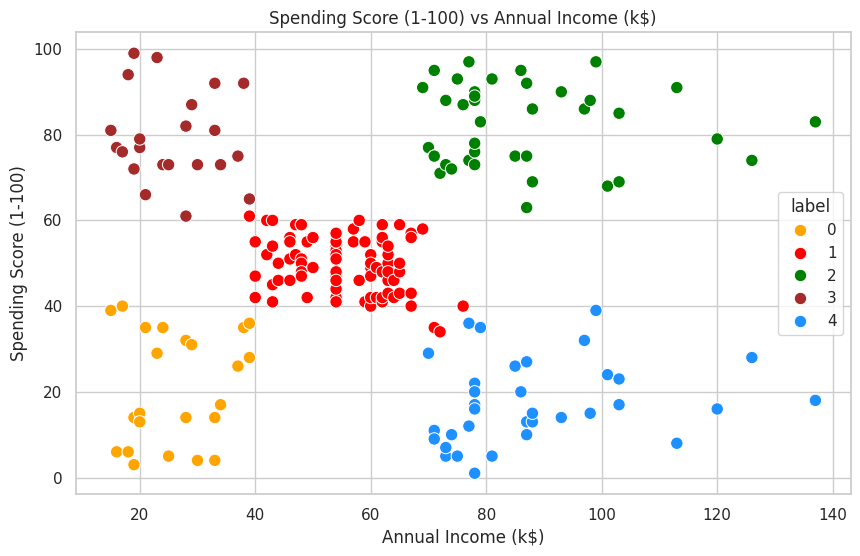

In [73]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = data, s= 80, hue='label',legend = "full", palette=['orange','red','green','brown','dodgerblue'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   label                   200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB


([<matplotlib.axis.XTick at 0x7fd236414da0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

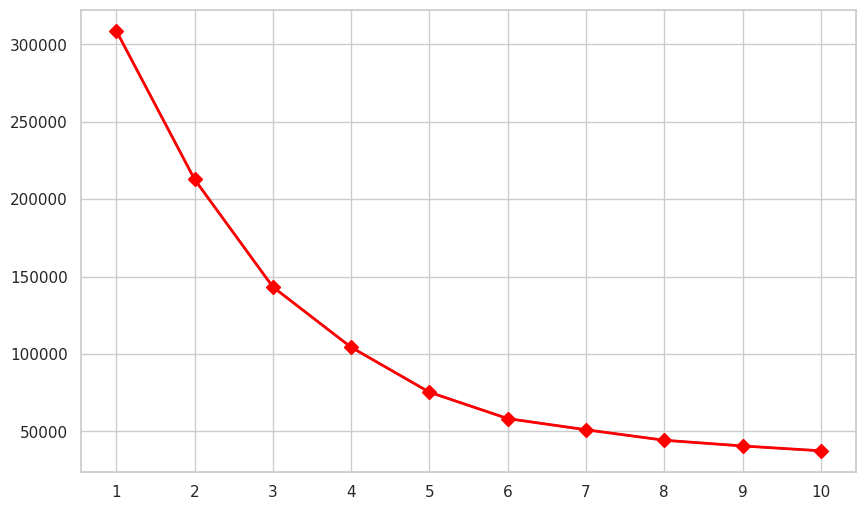

In [88]:
# k-Means Clustering on the basis of 3D data

X2 = data[['Age','Annual Income (k$)','Spending Score (1-100)']]

wss = []

for k in range(1,11):
  km_model = KMeans(k, init='k-means++',n_init=10)
  km_model.fit(X2)
  wss.append(km_model.inertia_)

plt.figure(2,figsize=(10,6))
plt.plot(range(1,11),wss)
plt.plot(range(1,11),wss, linewidth=2, color ='red', marker = 'D', markersize=7)
plt.xticks(range(1,11,1))


In [130]:

model = KMeans(n_clusters=5)

y = model.fit_predict(X2)

data['label1'] = y




Text(0.5, 0, 'Spending Score (1-100)')

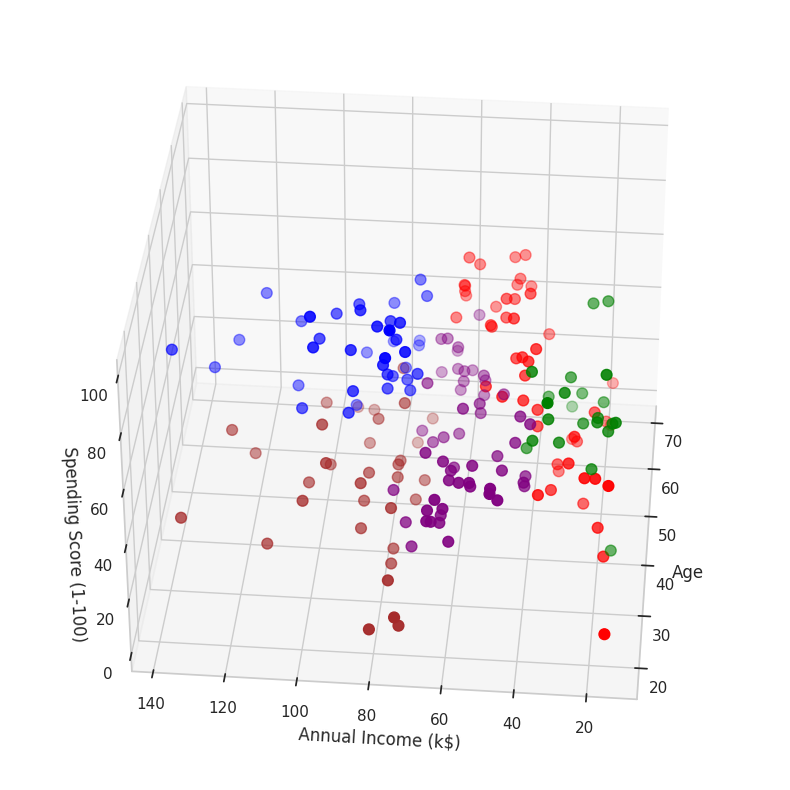

In [161]:
fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(data.Age[data['label1'] == 0], data['Annual Income (k$)'][data['label1'] == 0], data['Spending Score (1-100)'][data['label1'] == 0], color='red' ,s = 60)
ax.scatter(data.Age[data['label1'] == 1], data['Annual Income (k$)'][data['label1'] == 1], data['Spending Score (1-100)'][data['label1'] == 1], color='purple',s = 60 )
ax.scatter(data.Age[data['label1'] == 2], data['Annual Income (k$)'][data['label1'] == 2], data['Spending Score (1-100)'][data['label1'] == 2], color='blue',s = 60 )
ax.scatter(data.Age[data['label1'] == 3], data['Annual Income (k$)'][data['label1'] == 3], data['Spending Score (1-100)'][data['label1'] == 3], color='green',s = 60 )
ax.scatter(data.Age[data['label1'] == 4], data['Annual Income (k$)'][data['label1'] == 4], data['Spending Score (1-100)'][data['label1'] == 4], color='brown' ,s = 60)

ax.view_init(35,185)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
ax.set_zlabel('Spending Score (1-100)')



In [150]:

for i in range(0,5):
  cus = data[data['label1'] == i ]
  print("No of customers in the customers in {} group is : {}".format(i+1,len(cus)))
  print("They are Customer id is :{} ".format(cus['CustomerID'].to_numpy()))
  print("\n")

No of customers in the customers in 1 group is : 50
They are Customer id is :[  3   5   7   9  11  13  15  17  19  21  23  25  27  29  31  33  35  37
  39  41  43  45  47  51  54  55  56  57  58  60  61  63  64  65  68  71
  72  73  74  75  80  81  83  91 103 107 109 110 111 117] 


No of customers in the customers in 2 group is : 54
They are Customer id is :[ 44  48  49  50  52  53  59  62  66  67  69  70  76  77  78  79  82  84
  85  86  87  88  89  90  92  93  94  95  96  97  98  99 100 101 102 104
 105 106 108 112 113 114 115 116 118 119 120 121 122 123 125 127 133 143] 


No of customers in the customers in 3 group is : 39
They are Customer id is :[124 126 128 130 132 134 136 138 140 142 144 146 148 150 152 154 156 158
 160 162 164 166 168 170 172 174 176 178 180 182 184 186 188 190 192 194
 196 198 200] 


No of customers in the customers in 4 group is : 23
They are Customer id is :[ 1  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 46] 


No of customers in the cu